<a href="https://colab.research.google.com/github/saniyaverma/DGFL-for-plant-disease-detection/blob/main/Copy_of_22_OptimisingLabelSmoothing%2BLowerBackbone%2B7Rounds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Environment & Global Configuration

In [ ]:
# -------------------------------
# Device Configuration
# -------------------------------

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.10.0+cu128
CUDA available: True
Using device: cuda


In [ ]:
# -------------------------------
# Reproducibility
# -------------------------------

import os
import random
import numpy as np

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

set_seed(SEED)

print(f"All seeds fixed to {SEED}")

All seeds fixed to 42


In [ ]:
# -------------------------------
# Federated Configuration
# -------------------------------

NUM_CLIENTS = 2
NUM_ROUNDS = 7
LOCAL_EPOCHS = 2
BATCH_SIZE = 32

# -------------------------------
# Model Configuration
# -------------------------------

NUM_CLASSES = 10
FEATURE_DIM = 512
PRETRAINED = True

# -------------------------------
# Optimization
# -------------------------------

BASE_LR = 1e-3
BACKBONE_LR_FACTOR = 0.05
CLASSIFIER_LR_FACTOR = 1.0
DISCRIMINATOR_LR_FACTOR = 1.0
WEIGHT_DECAY = 1e-4

# -------------------------------
# Domain Generalization Configuration
# -------------------------------
LAMBDA_CORAL_MAX = 1.0
LAMBDA_DANN_MAX = 0.05
WARMUP = True

BUFFER_SIZE_PER_DOMAIN = 256
BUFFER_RECENT_PER_STEP = 128
BUFFER_RESET_EVERY = 2
RESET_BUFFER_ON_UNFREEZE = True
MIN_CORAL_SAMPLES = 8
COV_EPS = 1e-3

DG_GRAD_CLIP = 2.0
DROP_LAST_TRAIN = True

In [ ]:
# -------------------------------
# Utilities
# -------------------------------

import copy
import math

def get_lambda(round_idx, total_rounds, max_lambda):
    if not WARMUP:
        return max_lambda

    p = (round_idx - 1) / max(1, total_rounds - 1)
    return max_lambda * p

def weighted_fed_avg(models, dataset_sizes):
    global_dict = copy.deepcopy(models[0].state_dict())
    total_samples = sum(dataset_sizes)

    for key in global_dict.keys():
        if global_dict[key].dtype == torch.long:
            global_dict[key] = models[0].state_dict()[key]
        else:
            weighted_sum = 0
            for model, size in zip(models, dataset_sizes):
                weighted_sum += model.state_dict()[key] * (size / total_samples)

            global_dict[key] = weighted_sum

    return global_dict

Kaggle Setup & Dataset Download

In [ ]:
!pip install -q kaggle

In [ ]:
# from google.colab import files

# print("Upload kaggle.json")
# files.upload()

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API configured.")

Kaggle API configured.


In [ ]:
!kaggle datasets download -d ashishmotwani/tomato
!kaggle datasets download -d kaustubhb999/tomatoleaf
!kaggle datasets download -d luisolazo/tomato-diseases

!unzip -q tomato.zip -d tomato_A
!unzip -q tomatoleaf.zip -d tomato_B
!unzip -q tomato-diseases.zip -d tomato_unseen

print("Datasets extracted.")

Dataset URL: https://www.kaggle.com/datasets/ashishmotwani/tomato
License(s): copyright-authors
100% 1.37G/1.37G [00:10<00:00, 142MB/s]

Dataset URL: https://www.kaggle.com/datasets/kaustubhb999/tomatoleaf
License(s): CC0-1.0
100% 179M/179M [00:02<00:00, 91.5MB/s]

Dataset URL: https://www.kaggle.com/datasets/luisolazo/tomato-diseases
License(s): CC0-1.0
100% 411M/411M [00:02<00:00, 149MB/s]

Datasets extracted.


Dataset Preprocessing

In [ ]:
# ============================================================
# Folder Structure Inspection
# ============================================================

def show_tree(path, depth=3):
    for root, dirs, files in os.walk(path):
        level = root.replace(path, '').count(os.sep)
        if level < depth:
            print("  " * level + os.path.basename(root))

print("=== Dataset A ===")
show_tree("tomato_A")

print("\n=== Dataset B ===")
show_tree("tomato_B", depth=4)

print("\n=== Unseen Dataset ===")
show_tree("tomato_unseen")

=== Dataset A ===
tomato_A
  valid
    healthy
    Tomato_Yellow_Leaf_Curl_Virus
    Early_blight
    Target_Spot
    Leaf_Mold
    Spider_mites Two-spotted_spider_mite
    Late_blight
    Septoria_leaf_spot
    Bacterial_spot
    powdery_mildew
    Tomato_mosaic_virus
  train
    healthy
    Tomato_Yellow_Leaf_Curl_Virus
    Early_blight
    Target_Spot
    Leaf_Mold
    Spider_mites Two-spotted_spider_mite
    Late_blight
    Septoria_leaf_spot
    Bacterial_spot
    powdery_mildew
    Tomato_mosaic_virus

=== Dataset B ===
tomato_B
  tomato
    val
      Tomato___Bacterial_spot
      Tomato___Tomato_Yellow_Leaf_Curl_Virus
      Tomato___Target_Spot
      Tomato___healthy
      Tomato___Tomato_mosaic_virus
      Tomato___Septoria_leaf_spot
      Tomato___Spider_mites Two-spotted_spider_mite
      Tomato___Leaf_Mold
      Tomato___Early_blight
      Tomato___Late_blight
    train
      Tomato___Bacterial_spot
      Tomato___Tomato_Yellow_Leaf_Curl_Virus
      Tomato___Target_Spot
    

In [ ]:
# ============================================================
# Delete the extra class
# ============================================================

import shutil

paths_to_delete = [
    "tomato_A/train/powdery_mildew",
    "tomato_A/valid/powdery_mildew"
]

for p in paths_to_delete:
    if os.path.exists(p):
        shutil.rmtree(p)
        print(f"Deleted: {p}")

Deleted: tomato_A/train/powdery_mildew
Deleted: tomato_A/valid/powdery_mildew


In [ ]:
# ============================================================
# Inspect folder structures again
# ============================================================

def show_tree(path, depth=3):
    for root, dirs, files in os.walk(path):
        level = root.replace(path, '').count(os.sep)
        if level < depth:
            print("  " * level + os.path.basename(root))

print("=== Dataset A ===")
show_tree("tomato_A")

print("\n=== Dataset B ===")
show_tree("tomato_B", depth=4)

print("\n=== Unseen Dataset ===")
show_tree("tomato_unseen")

=== Dataset A ===
tomato_A
  valid
    healthy
    Tomato_Yellow_Leaf_Curl_Virus
    Early_blight
    Target_Spot
    Leaf_Mold
    Spider_mites Two-spotted_spider_mite
    Late_blight
    Septoria_leaf_spot
    Bacterial_spot
    Tomato_mosaic_virus
  train
    healthy
    Tomato_Yellow_Leaf_Curl_Virus
    Early_blight
    Target_Spot
    Leaf_Mold
    Spider_mites Two-spotted_spider_mite
    Late_blight
    Septoria_leaf_spot
    Bacterial_spot
    Tomato_mosaic_virus

=== Dataset B ===
tomato_B
  tomato
    val
      Tomato___Bacterial_spot
      Tomato___Tomato_Yellow_Leaf_Curl_Virus
      Tomato___Target_Spot
      Tomato___healthy
      Tomato___Tomato_mosaic_virus
      Tomato___Septoria_leaf_spot
      Tomato___Spider_mites Two-spotted_spider_mite
      Tomato___Leaf_Mold
      Tomato___Early_blight
      Tomato___Late_blight
    train
      Tomato___Bacterial_spot
      Tomato___Tomato_Yellow_Leaf_Curl_Virus
      Tomato___Target_Spot
      Tomato___healthy
      Tomato___Toma

In [ ]:
# ============================================================
# Dataset Scanning for any missing / corrupt values
# ============================================================

from PIL import Image
import pandas as pd
from tqdm import tqdm

def scan_dataset(root_dir, dataset_name):
    records = []
    broken = []

    for root, dirs, files in os.walk(root_dir):
      dirs.sort()
      files.sort()
      for file in files:
          if file.lower().endswith((".jpg", ".jpeg", ".png")):
              path = os.path.join(root, file)
              label = os.path.basename(root)
              try:
                  img = Image.open(path)
                  img.verify()
                  records.append({
                      "dataset": dataset_name,
                      "path": path,
                      "raw_label": label
                  })
              except:
                  broken.append(path)

    print(f"{dataset_name}: {len(records)} valid images")
    print(f"{dataset_name}: {len(broken)} broken images")

    return pd.DataFrame(records)

df_A = scan_dataset("tomato_A", "A")
df_B = scan_dataset("tomato_B/tomato", "B")
df_C = scan_dataset("tomato_unseen", "C")

df_raw = pd.concat([df_A, df_B, df_C]).reset_index(drop=True)

print("Total images:", len(df_raw))

A: 31278 valid images
A: 0 broken images
B: 11000 valid images
B: 0 broken images
C: 22193 valid images
C: 0 broken images
Total images: 64471


Label Harmonization

In [ ]:
# ============================================================
# Canonical Labels
# ============================================================

canonical_labels = [
    "bacterial_spot",
    "early_blight",
    "late_blight",
    "leaf_mold",
    "mosaic_virus",
    "septoria_leaf_spot",
    "spider_mites",
    "target_spot",
    "yellow_leaf_curl_virus",
    "healthy"
]

label_to_id = {label: idx for idx, label in enumerate(canonical_labels)}
id_to_label = {idx: label for idx, label in enumerate(canonical_labels)}

In [ ]:
# ============================================================
# Dataset-Specific Label Mapping
# ============================================================

mapping_A = {
    "Bacterial_spot": "bacterial_spot",
    "Early_blight": "early_blight",
    "Late_blight": "late_blight",
    "Leaf_Mold": "leaf_mold",
    "Tomato_mosaic_virus": "mosaic_virus",
    "Septoria_leaf_spot": "septoria_leaf_spot",
    "Spider_mites Two-spotted_spider_mite": "spider_mites",
    "Target_Spot": "target_spot",
    "Tomato_Yellow_Leaf_Curl_Virus": "yellow_leaf_curl_virus",
    "healthy": "healthy"
}

mapping_B = {
    "Tomato___Bacterial_spot": "bacterial_spot",
    "Tomato___Early_blight": "early_blight",
    "Tomato___Late_blight": "late_blight",
    "Tomato___Leaf_Mold": "leaf_mold",
    "Tomato___Tomato_mosaic_virus": "mosaic_virus",
    "Tomato___Septoria_leaf_spot": "septoria_leaf_spot",
    "Tomato___Spider_mites Two-spotted_spider_mite": "spider_mites",
    "Tomato___Target_Spot": "target_spot",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus": "yellow_leaf_curl_virus",
    "Tomato___healthy": "healthy"
}

mapping_C = {
    "bacterial_spot": "bacterial_spot",
    "early_blight": "early_blight",
    "late_blight": "late_blight",
    "leaf_mold": "leaf_mold",
    "mosaic_virus": "mosaic_virus",
    "septoria_leaf_spot": "septoria_leaf_spot",
    "twospotted_spider_mite": "spider_mites",
    "target_spot": "target_spot",
    "yellow_leaf_curl_virus": "yellow_leaf_curl_virus",
    "healthy": "healthy"
}

In [ ]:
# ============================================================
# Apply Harmonization
# ============================================================

def harmonize(row):
    if row['dataset'] == 'A':
        return mapping_A[row['raw_label']]
    elif row['dataset'] == 'B':
        return mapping_B[row['raw_label']]
    elif row['dataset'] == 'C':
        return mapping_C[row['raw_label']]

df_raw['canonical_label'] = df_raw.apply(harmonize, axis=1)
df_raw['class_id'] = df_raw['canonical_label'].map(label_to_id)

Client Mapping

In [ ]:
client_mapping = {
    'A': 0,
    'B': 1,
    'C': 2
}

df_raw['domain'] = df_raw['dataset'].map(client_mapping)

Domain Distribution per Dataset

In [ ]:
print("Domain distribution per dataset:")
print(df_raw.groupby(['dataset', 'domain']).size())

print("\nSample dataframe with domain labels:")
df_raw.head()

Domain distribution per dataset:
dataset  domain
A        0         31278
B        1         11000
C        2         22193
dtype: int64

Sample dataframe with domain labels:


,dataset,path,raw_label,canonical_label,class_id,domain
0,A,tomato_A/train/Bacterial_spot/00416648-be6e-4b...,Bacterial_spot,bacterial_spot,0,0
1,A,tomato_A/train/Bacterial_spot/0045ba29-ed1b-43...,Bacterial_spot,bacterial_spot,0,0
2,A,tomato_A/train/Bacterial_spot/00639d29-2d1a-4f...,Bacterial_spot,bacterial_spot,0,0
3,A,tomato_A/train/Bacterial_spot/00728f4d-83a0-49...,Bacterial_spot,bacterial_spot,0,0
4,A,tomato_A/train/Bacterial_spot/00a7c269-3476-4d...,Bacterial_spot,bacterial_spot,0,0


Client-Wise Train / Val / Test Split

In [ ]:
from sklearn.model_selection import train_test_split

def split_client(df, dataset_id):
    df_client = df[df['dataset'] == dataset_id].reset_index(drop=True)

    df_train, df_temp = train_test_split(
        df_client,
        train_size=0.8,
        stratify=df_client['class_id'],
        random_state=42
    )

    df_val, df_test = train_test_split(
        df_temp,
        train_size=0.5,
        stratify=df_temp['class_id'],
        random_state=42
    )

    return df_train, df_val, df_test

In [ ]:
df_train_A, df_val_A, df_test_A = split_client(df_raw, 'A')
df_train_B, df_val_B, df_test_B = split_client(df_raw, 'B')

df_unseen = df_raw[
    (df_raw['dataset'] == 'C') &
    (df_raw['path'].str.contains("test"))
].reset_index(drop=True)

print("Client A:", len(df_train_A), len(df_val_A), len(df_test_A))
print("Client B:", len(df_train_B), len(df_val_B), len(df_test_B))
print("Unseen Test:", len(df_unseen))

Client A: 25022 3128 3128
Client B: 8800 1100 1100
Unseen Test: 4440


Dataset Class

In [ ]:
from torch.utils.data import Dataset

class TomatoDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        label = row['class_id']

        if self.transform:
            image = self.transform(image)

        return image, label

Transforms

In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ColorJitter(0.4, 0.4, 0.4, 0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

Dataloaders

In [ ]:
from torch.utils.data import DataLoader

gA = torch.Generator()
gB = torch.Generator()
gA.manual_seed(SEED)
gB.manual_seed(SEED + 1)

train_loader_A = DataLoader(
TomatoDataset(df_train_A, train_transform),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=DROP_LAST_TRAIN,
    generator=gA
)
train_loader_B = DataLoader(
    TomatoDataset(df_train_B, train_transform),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=DROP_LAST_TRAIN,
    generator=gB
)

val_loader_A = DataLoader(TomatoDataset(df_val_A, val_transform), batch_size=BATCH_SIZE)
val_loader_B = DataLoader(TomatoDataset(df_val_B, val_transform), batch_size=BATCH_SIZE)

test_loader_A = DataLoader(TomatoDataset(df_test_A, val_transform), batch_size=BATCH_SIZE)
test_loader_B = DataLoader(TomatoDataset(df_test_B, val_transform), batch_size=BATCH_SIZE)

unseen_loader = DataLoader(TomatoDataset(df_unseen, val_transform), batch_size=BATCH_SIZE)

In [ ]:
client_dataset_sizes = [len(df_train_A), len(df_train_B)]

print("Client dataset sizes:", client_dataset_sizes)

Client dataset sizes: [25022, 8800]


Global Model

In [ ]:
# ============================================================
# Feature Extractor — ResNet18 (ImageNet pretrained)
# ============================================================

import torch.nn as nn
from torchvision import models

class FeatureExtractor(nn.Module):

    def __init__(self, pretrained=True):
        super(FeatureExtractor, self).__init__()

        self.backbone = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT if pretrained else None
        )

        self.backbone.fc = nn.Identity()

    def freeze_all(self):
        for param in self.backbone.parameters():
            param.requires_grad = False

    def unfreeze_layer4(self):
        for name, param in self.backbone.named_parameters():
            if "layer4" in name:
                param.requires_grad = True

    def unfreeze_all(self):
        for param in self.backbone.parameters():
            param.requires_grad = True

    def forward(self, x):
        return self.backbone(x)

Task Specific Head

In [ ]:
# ============================================================
# Classifier Head
# ============================================================

class Classifier(nn.Module):
    def __init__(self, in_dim=FEATURE_DIM, num_classes=NUM_CLASSES):
        super(Classifier, self).__init__()
        self.fc = nn.Linear(in_dim, num_classes)

    def forward(self, features):
        return self.fc(features)

Client Model (Feature Extractor + Classifier)

In [ ]:
class ClientModel(nn.Module):
    def __init__(self, pretrained=True):
        super(ClientModel, self).__init__()

        self.feature_extractor = FeatureExtractor(pretrained=pretrained)
        self.classifier = Classifier()

    def forward(self, x):
        features = self.feature_extractor(x)
        logits = self.classifier(features)
        return logits, features

Domain Generalization Components (CORAL + DANN)

In [ ]:
# ============================================================
# Gradient Reversal Layer
# ============================================================

from torch.autograd import Function

class GradReverse(Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.alpha * grad_output, None

In [ ]:
# ============================================================
# Domain Discriminator
# ============================================================

class DomainDiscriminator(nn.Module):
    def __init__(self, feature_dim=FEATURE_DIM, hidden_dim=256):
        super(DomainDiscriminator, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, NUM_CLIENTS)
        )

    def forward(self, features, alpha):
        reversed_features = GradReverse.apply(features, alpha)
        return self.net(reversed_features)

In [ ]:
# ============================================================
# CORAL Loss
# ============================================================

def stable_coral_loss(source, target, eps=COV_EPS):
    if source.size(0) < 2 or target.size(0) < 2:
        return torch.zeros((), device=source.device, dtype=source.dtype)

    d = source.size(1)
    source = source - source.mean(dim=0, keepdim=True)
    target = target - target.mean(dim=0, keepdim=True)

    cov_source = (source.T @ source) / (source.size(0) - 1)
    cov_target = (target.T @ target) / (target.size(0) - 1)

    eye = torch.eye(d, device=source.device, dtype=source.dtype)
    cov_source = cov_source + eps * eye
    cov_target = cov_target + eps * eye

    loss = torch.norm(cov_source - cov_target, p='fro') ** 2
    return loss / (4 * d * d)

In [ ]:
# ============================================================
# Feature Buffer
# ============================================================

class FeatureBuffer:
    def __init__(self, max_size, feature_dim):
        self.max_size = max_size
        self.feature_dim = feature_dim
        self.buffer = torch.empty((0, feature_dim), device=device)

    def add(self, features):
        self.buffer = torch.cat([self.buffer, features.detach()], dim=0)
        if self.buffer.size(0) > self.max_size:
            self.buffer = self.buffer[-self.max_size:]

    def get_recent(self, n):
        if self.buffer.size(0) == 0:
            return self.buffer
        n = min(n, self.buffer.size(0))
        return self.buffer[-n:]

In [ ]:
# ============================================================
# Server DG Module
# ============================================================

import torch.optim as optim

class ServerDG:
    def __init__(self):
        self.domain_discriminator = DomainDiscriminator().to(device)
        self.criterion_domain = nn.CrossEntropyLoss()

        self.optimizer_dd = optim.Adam(
            self.domain_discriminator.parameters(),
            lr=BASE_LR * DISCRIMINATOR_LR_FACTOR,
            weight_decay=WEIGHT_DECAY
        )

        self.reset_buffers()

    def reset_buffers(self):
        self.buffers = {
            0: FeatureBuffer(BUFFER_SIZE_PER_DOMAIN, FEATURE_DIM),
            1: FeatureBuffer(BUFFER_SIZE_PER_DOMAIN, FEATURE_DIM)
        }


    def compute_dg_grads(self, features_A, features_B, lambda_coral, lambda_dann, alpha):
        hist_A = self.buffers[0].get_recent(BUFFER_RECENT_PER_STEP)
        hist_B = self.buffers[1].get_recent(BUFFER_RECENT_PER_STEP)

        if hist_A.size(0) >= MIN_CORAL_SAMPLES and hist_B.size(0) >= MIN_CORAL_SAMPLES:
            combined_A = torch.cat([hist_A, features_A], dim=0)
            combined_B = torch.cat([hist_B, features_B], dim=0)
            loss_coral_hist = stable_coral_loss(combined_A, combined_B)
            loss_coral_curr = stable_coral_loss(features_A, features_B)
            loss_coral = 0.3 * loss_coral_hist + 0.7 * loss_coral_curr
        else:
            loss_coral = stable_coral_loss(features_A, features_B)

        domain_labels_A = torch.zeros(features_A.size(0), dtype=torch.long, device=device)
        domain_labels_B = torch.ones(features_B.size(0), dtype=torch.long, device=device)

        preds_A = self.domain_discriminator(features_A, alpha)
        preds_B = self.domain_discriminator(features_B, alpha)

        loss_dann_feature = (
            self.criterion_domain(preds_A, domain_labels_A) +
            self.criterion_domain(preds_B, domain_labels_B)
        ) / 2

        dg_loss = lambda_coral * loss_coral + lambda_dann * loss_dann_feature

        grad_A = torch.zeros_like(features_A)
        grad_B = torch.zeros_like(features_B)

        grad_inputs, grad_tags = [], []
        if features_A.requires_grad:
            grad_inputs.append(features_A)
            grad_tags.append("A")
        if features_B.requires_grad:
            grad_inputs.append(features_B)
            grad_tags.append("B")

        if grad_inputs:
            grads = torch.autograd.grad(
                outputs=dg_loss,
                inputs=grad_inputs,
                retain_graph=False,
                create_graph=False,
                allow_unused=True
            )
            for tag, g in zip(grad_tags, grads):
                if g is None:
                    continue
                if tag == "A":
                    grad_A = g.detach()
                else:
                    grad_B = g.detach()

        preds_A_det = self.domain_discriminator(features_A.detach(), alpha=0.0)
        preds_B_det = self.domain_discriminator(features_B.detach(), alpha=0.0)

        loss_dann_disc = (
            self.criterion_domain(preds_A_det, domain_labels_A) +
            self.criterion_domain(preds_B_det, domain_labels_B)
        ) / 2

        self.buffers[0].add(features_A)
        self.buffers[1].add(features_B)

        stats = {
            "dg_loss": dg_loss.detach(),
            "loss_coral": loss_coral.detach(),
            "loss_dann_feature": loss_dann_feature.detach(),
            "loss_dann_disc": loss_dann_disc
        }

        return grad_A, grad_B, stats

Federated Training Loop

In [ ]:
# ============================================================
# Client Training Module
# ============================================================

class ClientTrainer:
    def __init__(self, model, dataloader):
        self.model = model
        self.dataloader = dataloader
        self.criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
        self.model.feature_extractor.freeze_all()
        self.optimizer = self.get_optimizer()

    def get_optimizer(self):

        backbone_params = []
        classifier_params = []

        for name, param in self.model.named_parameters():

            if param.requires_grad:
                if "feature_extractor" in name:
                    backbone_params.append(param)
                elif "classifier" in name:
                    classifier_params.append(param)

        optimizer = optim.Adam(
            [
                {"params": backbone_params, "lr": BASE_LR * BACKBONE_LR_FACTOR},
                {"params": classifier_params, "lr": BASE_LR * CLASSIFIER_LR_FACTOR}
            ],
            weight_decay=WEIGHT_DECAY
        )

        return optimizer

    def unfreeze_layer4(self):
        print("Unfreezing layer4...")
        self.model.feature_extractor.unfreeze_layer4()
        self.optimizer = self.get_optimizer()

    def unfreeze_all(self):
        print("Unfreezing full backbone...")
        self.model.feature_extractor.unfreeze_all()
        self.optimizer = self.get_optimizer()

    def train_step(self, images, labels, dg_loss):

        self.model.train()
        self.optimizer.zero_grad()

        logits, features = self.model(images)

        task_loss = self.criterion(logits, labels)
        total_loss = task_loss + dg_loss

        total_loss.backward()
        self.optimizer.step()

        return features, task_loss

In [ ]:
# ============================================================
# Initialize Global Model + Clients + Server
# ============================================================

global_model = ClientModel(pretrained=PRETRAINED).to(device)

client_model_A = copy.deepcopy(global_model).to(device)
client_model_B = copy.deepcopy(global_model).to(device)

server_dg = ServerDG()

client_A = ClientTrainer(client_model_A, train_loader_A)
client_B = ClientTrainer(client_model_B, train_loader_B)

print("Backbone frozen. Training classifier only.")
print("All components initialized successfully.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 88.2MB/s]


Backbone frozen. Training classifier only.
All components initialized successfully.


In [ ]:
# ============================================================
# Validation Function
# ============================================================

def evaluate_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits, _ = model(images)
            preds = torch.argmax(logits, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return 100 * correct / total

In [36]:
# ============================================================
# Training Loop
# ============================================================

best_score = -1.0
best_global_state = None

for round_idx in range(1, NUM_ROUNDS + 1):
    print(f"\n================ ROUND {round_idx}/{NUM_ROUNDS} ================")

    if round_idx == 2:
        client_A.unfreeze_layer4()
        client_B.unfreeze_layer4()
        if RESET_BUFFER_ON_UNFREEZE:
            server_dg.reset_buffers()

    if round_idx == 4:
        client_A.unfreeze_all()
        client_B.unfreeze_all()
        if RESET_BUFFER_ON_UNFREEZE:
            server_dg.reset_buffers()

    if BUFFER_RESET_EVERY is not None and round_idx % BUFFER_RESET_EVERY == 0:
        print(f"Resetting feature buffers at round {round_idx}")
        server_dg.reset_buffers()

    lambda_coral = get_lambda(round_idx, NUM_ROUNDS, LAMBDA_CORAL_MAX)
    lambda_dann  = get_lambda(round_idx, NUM_ROUNDS, LAMBDA_DANN_MAX)

    p = (round_idx - 1) / max(1, NUM_ROUNDS - 1)
    alpha = 2 / (1 + math.exp(-10 * p)) - 1

    print(f"λ_CORAL: {lambda_coral:.4f} | λ_DANN: {lambda_dann:.4f} | alpha: {alpha:.4f}")

    for local_epoch in range(LOCAL_EPOCHS):
        print(f"\n--- Local Epoch {local_epoch+1}/{LOCAL_EPOCHS} ---")

        client_model_A.train()
        client_model_B.train()

        total_ce_A = 0.0
        total_ce_B = 0.0
        total_dg = 0.0
        total_disc = 0.0

        iterator_A = iter(train_loader_A)
        iterator_B = iter(train_loader_B)
        num_steps = max(len(train_loader_A), len(train_loader_B))

        for _ in range(num_steps):
            try:
                images_A, labels_A = next(iterator_A)
            except StopIteration:
                iterator_A = iter(train_loader_A)
                images_A, labels_A = next(iterator_A)

            try:
                images_B, labels_B = next(iterator_B)
            except StopIteration:
                iterator_B = iter(train_loader_B)
                images_B, labels_B = next(iterator_B)

            images_A, labels_A = images_A.to(device), labels_A.to(device)
            images_B, labels_B = images_B.to(device), labels_B.to(device)

            # Zero client grads
            client_A.optimizer.zero_grad(set_to_none=True)
            client_B.optimizer.zero_grad(set_to_none=True)

            # Client forwards + CE losses
            logits_A, features_A = client_model_A(images_A)
            loss_A = client_A.criterion(logits_A, labels_A)

            logits_B, features_B = client_model_B(images_B)
            loss_B = client_B.criterion(logits_B, labels_B)

            # Server computes DG grads from features
            dg_grad_A, dg_grad_B, dg_stats = server_dg.compute_dg_grads(
                features_A,
                features_B,
                lambda_coral,
                lambda_dann,
                alpha
            )

            dg_grad_A = torch.nan_to_num(dg_grad_A, nan=0.0, posinf=0.0, neginf=0.0)
            dg_grad_B = torch.nan_to_num(dg_grad_B, nan=0.0, posinf=0.0, neginf=0.0)
            dg_grad_A = dg_grad_A.clamp(-DG_GRAD_CLIP, DG_GRAD_CLIP)
            dg_grad_B = dg_grad_B.clamp(-DG_GRAD_CLIP, DG_GRAD_CLIP)

            # Client A: CE backward + injected DG gradient at split layer
            loss_A.backward(retain_graph=True)
            if features_A.requires_grad:
                features_A.backward(dg_grad_A)

            # Client B: CE backward + injected DG gradient at split layer
            loss_B.backward(retain_graph=True)
            if features_B.requires_grad:
                features_B.backward(dg_grad_B)

            # Client updates
            client_A.optimizer.step()
            client_B.optimizer.step()

            # Update discriminator (server-side only)
            server_dg.optimizer_dd.zero_grad(set_to_none=True)
            dg_stats["loss_dann_disc"].backward()
            server_dg.optimizer_dd.step()

            total_ce_A += loss_A.item()
            total_ce_B += loss_B.item()
            total_dg += dg_stats["dg_loss"].item()
            total_disc += dg_stats["loss_dann_disc"].item()

        # Validation after each local epoch
        val_acc_A = evaluate_accuracy(client_model_A, val_loader_A)
        val_acc_B = evaluate_accuracy(client_model_B, val_loader_B)

        print(
            f"Client A - CE: {total_ce_A/num_steps:.4f} | "
            f"Client B - CE: {total_ce_B/num_steps:.4f} | "
            f"DG: {total_dg/num_steps:.4f} | "
            f"Disc: {total_disc/num_steps:.4f} | "
            f"Val A: {val_acc_A:.2f}% | Val B: {val_acc_B:.2f}%"
        )

    # Federated Aggregation
    global_weights = weighted_fed_avg(
        [client_model_A, client_model_B],
        client_dataset_sizes
    )

    global_model.load_state_dict(global_weights)
    client_model_A.load_state_dict(global_model.state_dict())
    client_model_B.load_state_dict(global_model.state_dict())

    print("\n FedAvg complete.")

    # Global validation after each round
    global_val_A = evaluate_accuracy(global_model, val_loader_A)
    global_val_B = evaluate_accuracy(global_model, val_loader_B)
    global_score = 0.5 * (global_val_A + global_val_B)
    print(f"Global Model - Val A: {global_val_A:.2f}% | Val B: {global_val_B:.2f}% | Avg: {global_score:.2f}%")

    if global_score > best_score:
        best_score = global_score
        best_global_state = copy.deepcopy(global_model.state_dict())
        print(f"New best global checkpoint saved (Avg Val={best_score:.2f}%).")


================ ROUND 1/7 ================
λ_CORAL: 0.0000 | λ_DANN: 0.0000 | alpha: 0.0000

--- Local Epoch 1/2 ---
Client A - CE: 1.3902 | Client B - CE: 1.1904 | DG: 0.0000 | Disc: 0.5722 | Val A: 70.49% | Val B: 75.27%

--- Local Epoch 2/2 ---
Client A - CE: 1.1602 | Client B - CE: 0.9317 | DG: 0.0000 | Disc: 0.4879 | Val A: 72.54% | Val B: 78.00%

 FedAvg complete.
Global Model - Val A: 71.20% | Val B: 78.36% | Avg: 74.78%
New best global checkpoint saved (Avg Val=74.78%).

================ ROUND 2/7 ================
Unfreezing layer4...
Unfreezing layer4...
Resetting feature buffers at round 2
λ_CORAL: 0.1667 | λ_DANN: 0.0083 | alpha: 0.6823

--- Local Epoch 1/2 ---
Client A - CE: 0.8850 | Client B - CE: 0.6891 | DG: 0.0036 | Disc: 0.3563 | Val A: 83.66% | Val B: 92.18%

--- Local Epoch 2/2 ---
Client A - CE: 0.7011 | Client B - CE: 0.5286 | DG: 0.0017 | Disc: 0.1388 | Val A: 89.93% | Val B: 93.82%

 FedAvg complete.
Global Model - Val A: 89.19% | Val B: 95.18% | Avg: 92.19%
Ne

Evaluation

In [37]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import torch.nn.functional as F

def evaluate_model(model, loader):

    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            logits, _ = model(images)
            probs = F.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
            all_probs.append(probs.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_probs = torch.cat(all_probs).numpy()

    # Classification report
    cls_report = classification_report(all_labels, all_preds, digits=4)

    # Confusion matrix
    conf_matrix = confusion_matrix(all_labels, all_preds)

    # AUROC (multi-class)
    try:
        auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    except:
        auc = None

    return cls_report, conf_matrix, auc

In [38]:
# Confusion Matrix Visualization
import matplotlib.pyplot as plt
import seaborn as sns

id_to_label = {idx: label for label, idx in label_to_id.items()}

def plot_confusion_matrix(conf_matrix, title):

    plt.figure(figsize=(8,6))

    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=list(id_to_label.values()),
        yticklabels=list(id_to_label.values())
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

In [39]:
if best_global_state is not None:
    global_model.load_state_dict(best_global_state)
    print(f"Loaded best global model (Avg Val={best_score:.2f}%) for final testing.")

Loaded best global model (Avg Val=98.92%) for final testing.



================ CLIENT A TEST ================
              precision    recall  f1-score   support

           0     0.9830    0.9719    0.9774       356
           1     0.9613    0.9613    0.9613       310
           2     0.9668    0.9692    0.9680       390
           3     0.9885    0.9857    0.9871       349
           4     0.9963    0.9818    0.9890       274
           5     0.9510    0.9614    0.9562       363
           6     0.9909    1.0000    0.9954       218
           7     1.0000    0.9913    0.9956       229
           8     0.9961    1.0000    0.9980       254
           9     0.9871    0.9948    0.9909       385

    accuracy                         0.9802      3128
   macro avg     0.9821    0.9817    0.9819      3128
weighted avg     0.9802    0.9802    0.9802      3128

AUROC: 0.9994743366913206


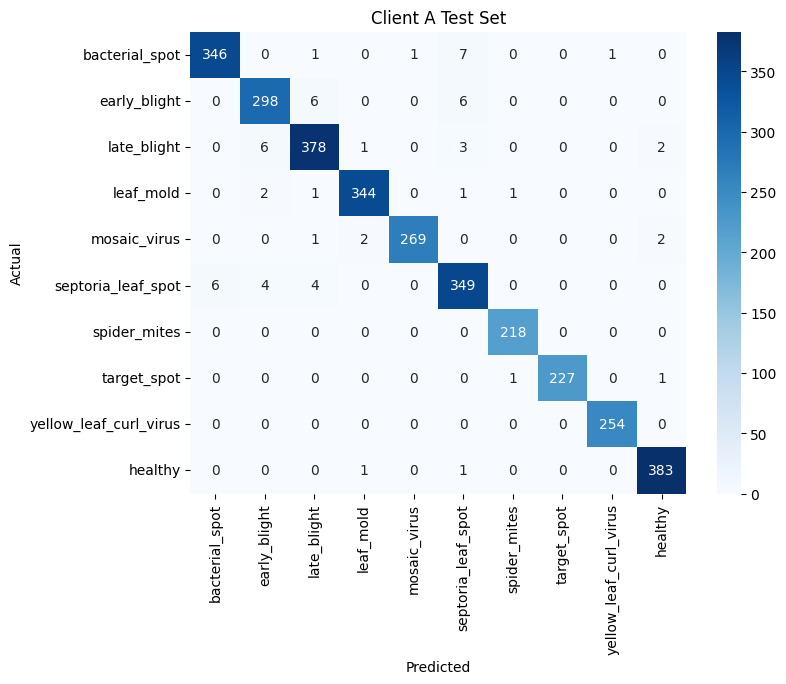

In [40]:
print("\n================ CLIENT A TEST ================")

report_A, conf_A, auc_A = evaluate_model(global_model, test_loader_A)

print(report_A)
print("AUROC:", auc_A)

plot_confusion_matrix(conf_A, "Client A Test Set")


================ CLIENT B TEST ================
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       110
           1     1.0000    0.9455    0.9720       110
           2     0.9735    1.0000    0.9865       110
           3     1.0000    0.9909    0.9954       110
           4     0.9910    1.0000    0.9955       110
           5     0.9821    1.0000    0.9910       110
           6     0.9910    1.0000    0.9955       110
           7     0.9909    0.9909    0.9909       110
           8     1.0000    1.0000    1.0000       110
           9     1.0000    1.0000    1.0000       110

    accuracy                         0.9927      1100
   macro avg     0.9928    0.9927    0.9927      1100
weighted avg     0.9928    0.9927    0.9927      1100

AUROC: 0.9999871441689624


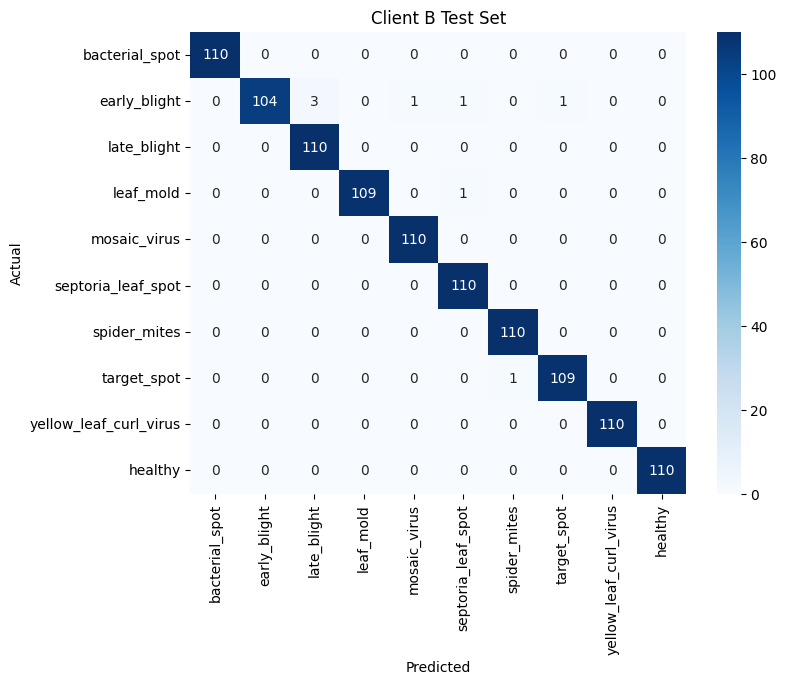

In [45]:
print("\n================ CLIENT B TEST ================")

report_B, conf_B, auc_B = evaluate_model(global_model, test_loader_B)

print(report_B)
print("AUROC:", auc_B)

plot_confusion_matrix(conf_B, "Client B Test Set")


================ UNSEEN DOMAIN TEST ================
              precision    recall  f1-score   support

           0     0.9589    0.9977    0.9779       444
           1     0.9727    0.8018    0.8790       444
           2     0.9114    0.8806    0.8958       444
           3     0.8516    0.9820    0.9121       444
           4     0.9780    1.0000    0.9889       444
           5     0.8827    1.0000    0.9377       444
           6     0.9867    1.0000    0.9933       444
           7     0.9888    0.9977    0.9933       444
           8     0.9933    0.9977    0.9955       444
           9     0.9703    0.8086    0.8821       444

    accuracy                         0.9466      4440
   macro avg     0.9494    0.9466    0.9456      4440
weighted avg     0.9494    0.9466    0.9456      4440

AUROC: 0.9979432134837541


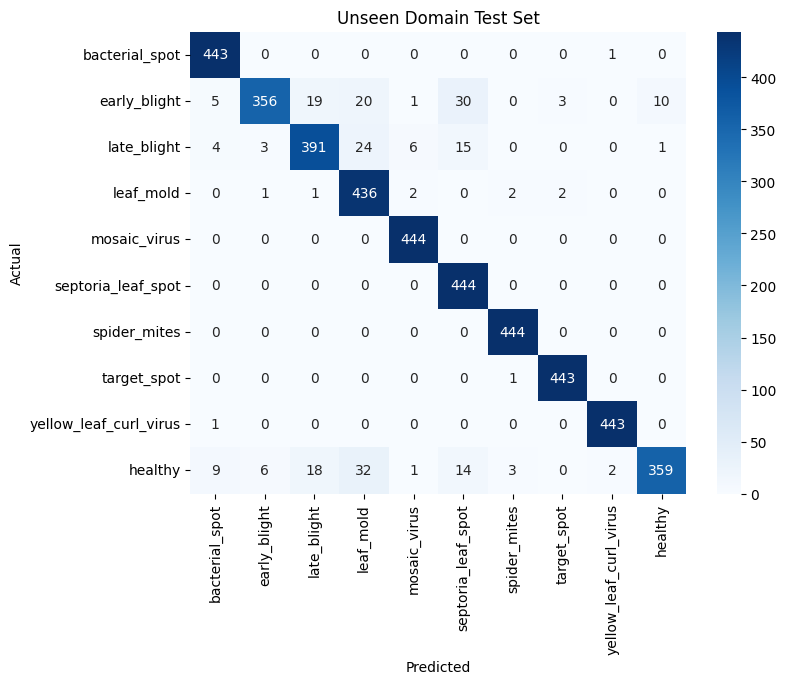

In [44]:
print("\n================ UNSEEN DOMAIN TEST ================")

report_U, conf_U, auc_U = evaluate_model(global_model, unseen_loader)

print(report_U)
print("AUROC:", auc_U)

plot_confusion_matrix(conf_U, "Unseen Domain Test Set")